# IQR (Interquartile Range) Anomaly Detection
## An Interactive Presentation

**Library:** `ifri_mini_ml_lib`

---

### Table of Contents
1. What is IQR?
2. Key Concepts
3. Why IQR is Robust?
4. Implementation with `ifri_mini_ml_lib`
5. Interactive Demo
6. Real-Life Applications
7. Limits and Challenges
8. Comparison between `ifri_mini_ml_lib` and scikit-learn
9. References

In [11]:
# Import required libraries
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider
import warnings
warnings.filterwarnings('ignore')
import importlib.util

# Load IQR module from ifri_mini_ml_lib
chemin_iqr = os.path.join(
    os.path.abspath ('../..'),
    'ifri_mini_ml_lib', 'anomalies_detection', 'iqr.py'
)

if os.path.exists(chemin_iqr):
    print(f"File found: {chemin_iqr}")
else:
    print(f"File NOT found: {chemin_iqr}")
    print("Please check the path.")

spec = importlib.util.spec_from_file_location("iqr", chemin_iqr)
iqr_module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(iqr_module)

IQR = iqr_module.IQR

# Scikit-learn imports
from sklearn.datasets import load_iris, fetch_california_housing
from sklearn.preprocessing import RobustScaler

print("All libraries imported successfully!")
print(f"IQR module loaded from: {os.path.abspath('..')}")

File found: c:\Users\HP\Desktop\ifri_mini_ml_lib\ifri_mini_ml_lib\anomalies_detection\iqr.py
All libraries imported successfully!
IQR module loaded from: c:\Users\HP\Desktop\ifri_mini_ml_lib\notebooks


## 1. What is IQR? 

### Definition
The **IQR (Interquartile Range)** is a robust statistical measure that captures the spread of the **middle 50%** of the data. It is used to detect anomalies by defining boundaries beyond which values are considered outliers.

### The Formula

$$ IQR = Q3 - Q1 $$

Where:
- **Q1** = 25th percentile (first quartile)
- **Q3** = 75th percentile (third quartile)

### Tukey's Fences (Anomaly Bounds)

$$ \text{Lower Fence} = Q1 - k \times IQR $$
$$ \text{Upper Fence} = Q3 + k \times IQR $$

Where **k = 1.5** (standard Tukey rule, 1977).

### Anomaly Condition
A value **x** is flagged as an anomaly if:

$$ x < \text{Lower Fence} \quad \text{OR} \quad x > \text{Upper Fence} $$

### Simple Example
Given the dataset: `[5, 7, 8, 9, 10, 11, 12, 13, 14, 100]`
- Q1 = 8.25, Q3 = 13.25, IQR = 5.0
- Lower Fence = 8.25 - 1.5 × 5.0 = **0.75**
- Upper Fence = 13.25 + 1.5 × 5.0 = **20.75**
- Value **100 > 20.75** → **ANOMALY!** 🚨

## 2. Key Concepts 

### 2.1 Quartiles and Box Plot
The IQR is the foundation of the **Box Plot** (or Box-and-Whisker Plot), a standard visualization tool.

```
        Q1      Median     Q3
        |         |         |
|-------|=========|=========|-------|
Min   Lower              Upper    Max
      Fence              Fence
```

### 2.2 Why k = 1.5?
| k value | Coverage | Use case |
|---------|----------|---------|
| k = 1.5 | ~99.3% of normal data | Standard Tukey rule |
| k = 3.0 | ~99.99% of normal data | Extreme anomalies only |

### 2.3 Advantages over Z-Score
| Property | Z-Score | IQR |
|----------|---------|-----|
| Uses mean | ✅ Yes (sensitive) | ❌ No (robust) |
| Assumes normal distribution | ✅ Yes | ❌ No |
| Robust to outliers | ❌ No | ✅ Yes |
| Works on any distribution | ❌ No | ✅ Yes |

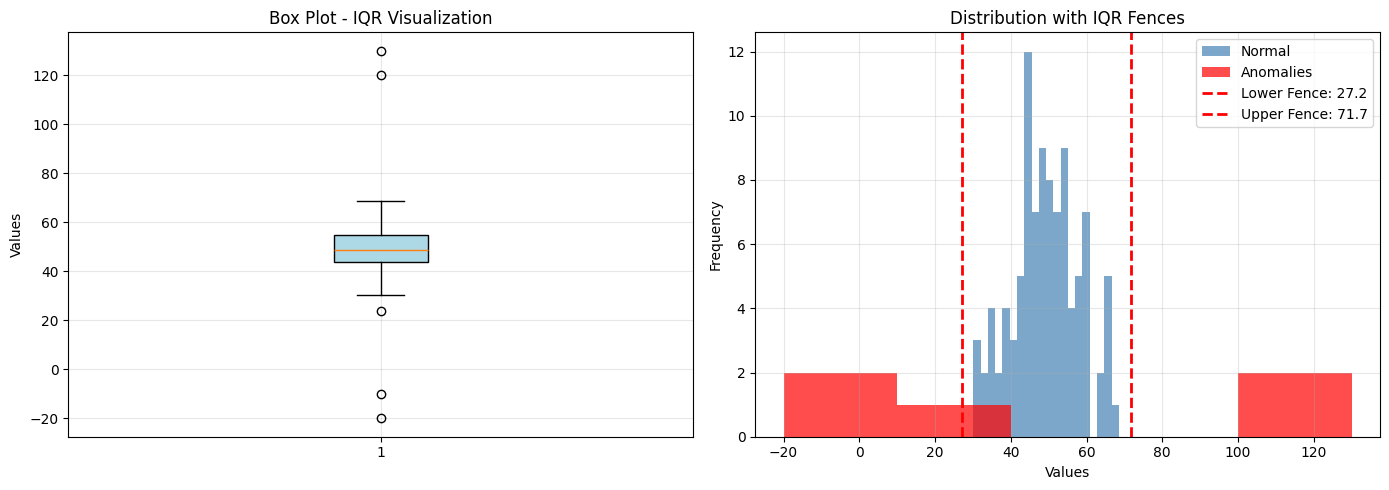

Q1 = 43.87 | Q3 = 55.01 | IQR = 11.13
Lower Fence = 27.17 | Upper Fence = 71.71
Anomalies detected: 5


In [12]:
# Visual demonstration of IQR concept
np.random.seed(42)
data = np.concatenate([
    np.random.normal(50, 10, 100),
    [120, 130, -10, -20]  # outliers
])

Q1 = np.percentile(data, 25)
Q3 = np.percentile(data, 75)
IQR_val = Q3 - Q1
lower = Q1 - 1.5 * IQR_val
upper = Q3 + 1.5 * IQR_val

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
axes[0].boxplot(data, vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue'))
axes[0].set_title('Box Plot - IQR Visualization')
axes[0].set_ylabel('Values')
axes[0].grid(True, alpha=0.3)

# Distribution with fences
normal = data[(data >= lower) & (data <= upper)]
outliers = data[(data < lower) | (data > upper)]

axes[1].hist(normal, bins=20, color='steelblue', alpha=0.7, label='Normal')
axes[1].hist(outliers, bins=5, color='red', alpha=0.7, label='Anomalies')
axes[1].axvline(lower, color='red', linestyle='--', linewidth=2,
                label=f'Lower Fence: {lower:.1f}')
axes[1].axvline(upper, color='red', linestyle='--', linewidth=2,
                label=f'Upper Fence: {upper:.1f}')
axes[1].set_title('Distribution with IQR Fences')
axes[1].set_xlabel('Values')
axes[1].set_ylabel('Frequency')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Q1 = {Q1:.2f} | Q3 = {Q3:.2f} | IQR = {IQR_val:.2f}")
print(f"Lower Fence = {lower:.2f} | Upper Fence = {upper:.2f}")
print(f"Anomalies detected: {len(outliers)}")

## 3. Why IQR is Robust? 

### The Problem with Mean-based Methods
Methods like Z-Score use the **mean** and **standard deviation**, which are heavily influenced by outliers.

### Demonstration: Mean vs Median under outlier influence

In [13]:
# Demonstrate robustness of IQR vs Z-Score
normal_data = np.array([10, 12, 11, 13, 10, 12, 11, 14, 10, 13])
data_with_outlier = np.append(normal_data, [200, 300])

print("=" * 60)
print("ROBUSTNESS DEMONSTRATION: IQR vs Z-Score")
print("=" * 60)

print("\n CLASSIC STATISTICS (affected by outliers):")
print(f"   Mean (clean data)     : {np.mean(normal_data):.2f}")
print(f"   Mean (with outliers)  : {np.mean(data_with_outlier):.2f}  ← distorted!")
print(f"   Std  (clean data)     : {np.std(normal_data):.2f}")
print(f"   Std  (with outliers)  : {np.std(data_with_outlier):.2f}  ← distorted!")

print("\n ROBUST STATISTICS (resistant to outliers):")
print(f"   Median (clean data)   : {np.median(normal_data):.2f}")
print(f"   Median (with outliers): {np.median(data_with_outlier):.2f}  ← stable!")
Q1_c = np.percentile(normal_data, 25)
Q3_c = np.percentile(normal_data, 75)
Q1_o = np.percentile(data_with_outlier, 25)
Q3_o = np.percentile(data_with_outlier, 75)
print(f"   IQR   (clean data)    : {Q3_c - Q1_c:.2f}")
print(f"   IQR   (with outliers) : {Q3_o - Q1_o:.2f}  ← stable!")

ROBUSTNESS DEMONSTRATION: IQR vs Z-Score

 CLASSIC STATISTICS (affected by outliers):
   Mean (clean data)     : 11.60
   Mean (with outliers)  : 51.33  ← distorted!
   Std  (clean data)     : 1.36
   Std  (with outliers)  : 91.17  ← distorted!

 ROBUST STATISTICS (resistant to outliers):
   Median (clean data)   : 11.50
   Median (with outliers): 12.00  ← stable!
   IQR   (clean data)    : 2.50
   IQR   (with outliers) : 2.50  ← stable!


## 4. Implementation with `ifri_mini_ml_lib` 

### The `IQR` class

```python
from ifri_mini_ml_lib.anomalies_detection.iqr import IQR

detector = IQR(factor=1.5)
detector.fit(X)        # Compute Q1, Q3, IQR, bounds
labels = detector.predict(X)   # 0 = normal, 1 = anomaly
```

### Key Parameters
| Parameter | Default | Description |
|-----------|---------|-------------|
| `factor` | 1.5 | IQR multiplier for fence computation |
| `handle_nan` | `'raise'` | NaN strategy: `'raise'` or `'omit'` |

### Key Methods
| Method | Description |
|--------|-------------|
| `fit(X)` | Compute Q1, Q3, IQR and fences |
| `predict(X)` | Return anomaly labels (0/1) |
| `fit_predict(X)` | fit + predict in one call |
| `get_bounds()` | Return lower and upper fences |
| `summary()` | Print fitted parameters |

In [14]:
# Basic usage demonstration
print("=" * 60)
print("BASIC USAGE - ifri_mini_ml_lib IQR")
print("=" * 60)

# Simple 1D example
X_simple = [[10], [11], [12], [13], [14], [15], [16], [100], [-50]]

detector = IQR(factor=1.5)
labels = detector.fit_predict(X_simple)

print("\nData    | Label")
print("-" * 20)
for val, label in zip(X_simple, labels):
    status = "ANOMALY" if label == 1 else "normal"
    print(f"{val[0]:6} | {status}")

print()
detector.summary()

BASIC USAGE - ifri_mini_ml_lib IQR

Data    | Label
--------------------
    10 | normal
    11 | normal
    12 | normal
    13 | normal
    14 | normal
    15 | normal
    16 | normal
   100 | ANOMALY
   -50 | ANOMALY

         IQR Detector Summary
Factor: 1.5
Features: 1
  Feature 0: [5.0000, 21.0000]


APPLICATION - IRIS DATASET

sepal length (cm)
   Anomalies : 0
   Lower fence: 3.150
   Upper fence: 8.350

sepal width (cm)
   Anomalies : 4
   Lower fence: 2.050
   Upper fence: 4.050

petal length (cm)
   Anomalies : 0
   Lower fence: -3.650
   Upper fence: 10.350

petal width (cm)
   Anomalies : 0
   Lower fence: -1.950
   Upper fence: 4.050


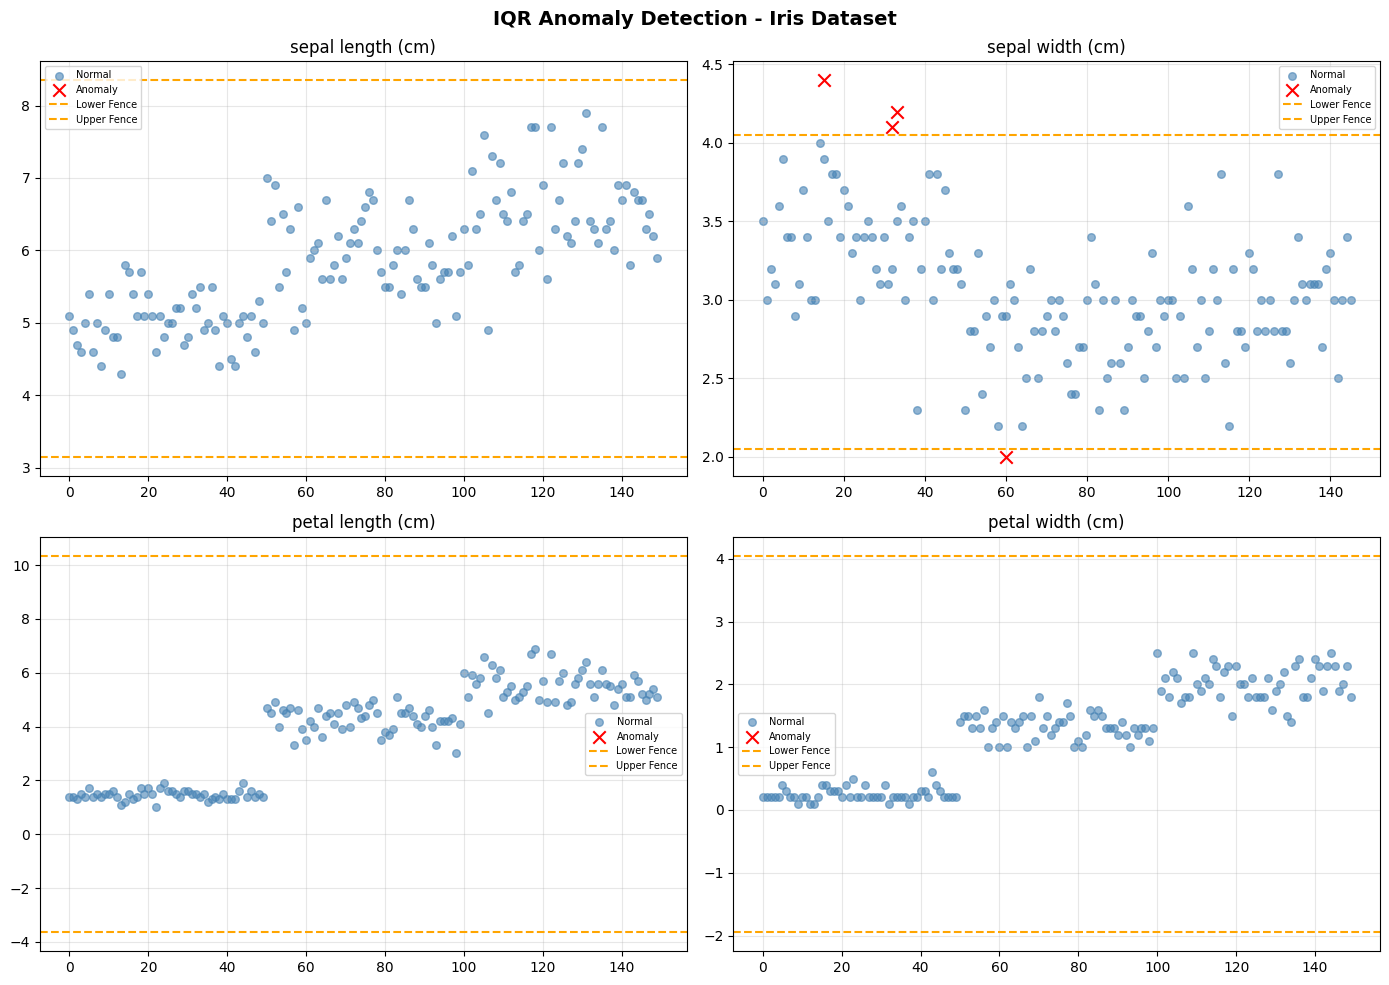

In [15]:
# Application on Iris dataset
print("=" * 60)
print("APPLICATION - IRIS DATASET")
print("=" * 60)

iris = load_iris()
data_iris = pd.DataFrame(iris.data, columns=iris.feature_names)

results = {}
for col in data_iris.columns:
    det = IQR(factor=1.5)
    X_col = data_iris[[col]].values
    labels = det.fit_predict(X_col)
    results[col] = {
        'anomalies': np.sum(labels),
        'lower': det.lower_bound_[0],
        'upper': det.upper_bound_[0]
    }
    print(f"\n{col}")
    print(f"   Anomalies : {np.sum(labels)}")
    print(f"   Lower fence: {det.lower_bound_[0]:.3f}")
    print(f"   Upper fence: {det.upper_bound_[0]:.3f}")

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, col in enumerate(data_iris.columns):
    det = IQR(factor=1.5)
    X_col = data_iris[[col]].values
    labels = det.fit_predict(X_col)

    normal_vals = data_iris[col][labels == 0]
    anomaly_vals = data_iris[col][labels == 1]

    axes[idx].scatter(range(len(normal_vals)), normal_vals.values,
                      color='steelblue', alpha=0.6, label='Normal', s=30)
    axes[idx].scatter(anomaly_vals.index, anomaly_vals.values,
                      color='red', s=80, zorder=5, label='Anomaly', marker='x')
    axes[idx].axhline(det.lower_bound_[0], color='orange', linestyle='--',
                      linewidth=1.5, label='Lower Fence')
    axes[idx].axhline(det.upper_bound_[0], color='orange', linestyle='--',
                      linewidth=1.5, label='Upper Fence')
    axes[idx].set_title(col)
    axes[idx].legend(fontsize=7)
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('IQR Anomaly Detection - Iris Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Interactive Demo 

Adjust the **factor k** and observe how the anomaly boundaries change!

In [ ]:
# Interactive demo with ipywidgets
np.random.seed(42)
demo_data = np.concatenate([
    np.random.normal(50, 10, 100),
    [120, 130, -10, -20]
])

def interactive_iqr(factor=1.5):
    Q1 = np.percentile(demo_data, 25)
    Q3 = np.percentile(demo_data, 75)
    IQR_val = Q3 - Q1
    lower = Q1 - factor * IQR_val
    upper = Q3 + factor * IQR_val

    normal = demo_data[(demo_data >= lower) & (demo_data <= upper)]
    outliers = demo_data[(demo_data < lower) | (demo_data > upper)]

    plt.figure(figsize=(12, 5))
    plt.scatter(range(len(demo_data)), sorted(demo_data),
                color='steelblue', alpha=0.5, label='Normal', s=20)
    outlier_idx = [i for i, v in enumerate(sorted(demo_data)) if v < lower or v > upper]
    plt.scatter(outlier_idx, [sorted(demo_data)[i] for i in outlier_idx],
                color='red', s=80, zorder=5, label=f'Anomalies ({len(outliers)})', marker='x')
    plt.axhline(lower, color='orange', linestyle='--', linewidth=2,
                label=f'Lower Fence: {lower:.1f}')
    plt.axhline(upper, color='orange', linestyle='--', linewidth=2,
                label=f'Upper Fence: {upper:.1f}')
    plt.title(f'IQR Anomaly Detection (k = {factor})')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    print(f"Q1={Q1:.1f} | Q3={Q3:.1f} | IQR={IQR_val:.1f}")
    print(f"Anomalies detected: {len(outliers)}/{len(demo_data)}")

interact(interactive_iqr,
         factor=FloatSlider(min=0.5, max=3.5, step=0.5, value=1.5, description='k factor:'))

## 6. Real-Life Applications 

| Domain | Use Case |
|--------|----------|
| 🏦 **Finance** | Detecting fraudulent transactions |
| 🏭 **Industry** | Predictive maintenance (sensor anomalies) |
| 🏥 **Healthcare** | Detecting abnormal patient vitals |
| 🌡️ **Environment** | Detecting extreme weather measurements |
| 🛒 **E-commerce** | Detecting abnormal purchase behaviors |

In [ ]:
# Real-life application: California Housing
print("=" * 60)
print("REAL-LIFE APPLICATION - California Housing Dataset")
print("=" * 60)

housing = fetch_california_housing()
df_housing = pd.DataFrame(housing.data, columns=housing.feature_names)

# Detect anomalies on all features
print(f"\nDataset: {df_housing.shape[0]} samples, {df_housing.shape[1]} features\n")

for col in df_housing.columns:
    det = IQR(factor=1.5)
    labels = det.fit_predict(df_housing[[col]].values)
    pct = np.sum(labels) / len(labels) * 100
    print(f"{col:12} | Anomalies: {np.sum(labels):4d} ({pct:.1f}%)")

REAL-LIFE APPLICATION - California Housing Dataset


NameError: name 'fetch_california_housing' is not defined

## 7. Limits and Challenges 

### Limitations of the IQR Method

| Limitation | Description |
|------------|-------------|
| **Univariate** | Analyzes one column at a time — misses multivariate anomalies |
| **Symmetric assumption** | Assumes outliers can be on both sides equally |
| **Fixed k** | k = 1.5 may not suit all datasets |
| **High dimensions** | Not directly applicable to high-dimensional data |

### When to use IQR vs other methods

| Scenario | Best method |
|----------|-------------|
| Simple univariate data | ✅ IQR |
| Non-gaussian distribution | ✅ IQR |
| Multivariate data | ❌ Use LOF or Isolation Forest |
| Need probabilistic scores | ❌ Use Z-Score |

## 8. Comparison between `ifri_mini_ml_lib` and scikit-learn

We compare our `IQR` implementation against **scikit-learn's `RobustScaler`**, which uses the same IQR logic internally.

In [ ]:
import time

# Test data: 1000 points with 50 real anomalies
np.random.seed(42)
data_bench = np.concatenate([
    np.random.normal(100, 15, 950),
    np.random.uniform(200, 500, 50)
])
np.random.shuffle(data_bench)

print(f" {len(data_bench)} data points, 50 real anomalies")
print("=" * 60)

# --- ifri_mini_ml_lib ---
detector_ifri = IQR(factor=1.5)
start = time.time()
labels_ifri = detector_ifri.fit_predict(data_bench.reshape(-1, 1))
time_ifri = time.time() - start

print(f"\n ifri_mini_ml_lib:")
print(f"   Time: {time_ifri*1000:.2f} ms")
print(f"   Anomalies: {np.sum(labels_ifri)}")
print(f"   IQR computed: {detector_ifri.IQR_[0]:.4f}")

# --- scikit-learn RobustScaler ---
scaler = RobustScaler()
start = time.time()
scaler.fit(data_bench.reshape(-1, 1))
time_sklearn = time.time() - start

print(f"\n scikit-learn (RobustScaler):")
print(f"   Time: {time_sklearn*1000:.2f} ms")
print(f"   IQR computed: {scaler.scale_[0]:.4f}")

# --- Comparison ---
iqr_match = round(detector_ifri.IQR_[0], 4) == round(scaler.scale_[0], 4)
print("\n" + "=" * 60)
print("COMPARISON:")
print(f"   ifri_mini_ml_lib : {time_ifri*1000:.2f} ms")
print(f"   scikit-learn     : {time_sklearn*1000:.2f} ms")
print(f"   IQR values match : {'✅ Yes' if iqr_match else '❌ No'}")

# Visualization
categories = ['ifri_mini_ml_lib', 'scikit-learn']
times = [time_ifri*1000, time_sklearn*1000]
colors = ['steelblue', 'tomato']

plt.figure(figsize=(7, 4))
bars = plt.bar(categories, times, color=colors, alpha=0.8)
for bar, t in zip(bars, times):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{t:.2f} ms', ha='center', va='bottom', fontweight='bold')
plt.title('Execution Time Comparison')
plt.ylabel('Time (ms)')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## 9. References 

### Academic References

1. **Tukey, J. W. (1977).**  
   *Exploratory Data Analysis*. Addison-Wesley.  
   *(Original paper introducing the IQR fences with k = 1.5)*

2. **Aggarwal, C. C. (2017).**  
   *Outlier Analysis* (2nd ed.). Springer.  
   ISBN: 978-3-319-47578-3

3. **Rousseeuw, P. J., & Hubert, M. (2011).**  
   Robust statistics for outlier detection.  
   *WIREs Data Mining and Knowledge Discovery*, 1(1), 73-79.

### Online Resources

- [NIST/SEMATECH e-Handbook of Statistical Methods](https://www.itl.nist.gov/div898/handbook/)
- [Scikit-learn Outlier Detection Documentation](https://scikit-learn.org/stable/modules/outlier_detection.html)

### Software & Libraries

- `ifri_mini_ml_lib` - Custom implementation ([GitHub](https://github.com/IFRI-AI-Classes/ifri_mini_ml_lib))
- `scikit-learn` - Machine learning library
- `NumPy` - Numerical computing
- `Matplotlib` - Visualization
- `pandas` - Data manipulation

### About This Implementation

This notebook uses the custom `ifri_mini_ml_lib` library, which implements:
- `IQR` class with `fit()`, `predict()`, `fit_predict()`, `get_bounds()`, `summary()`
- Support for 1D and multivariate data
- NaN handling and Zero IQR protection

---

## Thank You! 🎉